# 05 - Conditioning Variable Selection

Purpose:
- decide whether Brent, DXY, VIX, and US10Y should be trigger inputs or diagnostic context;
- compare Gold-only versus Gold-plus-conditioning-variable variants;
- test whether conditioning variables improve nowcasting coverage, false review burden, or interpretation;
- make the transition from Gold-only evidence to final alarm design explicit.

Research gap addressed:
The earlier notebooks show that Gold alone is imperfect but useful. Before adding multiple market variables to the alarm itself, we need to test whether those variables improve the practical operating point. If they do not, Gold should remain the primary trigger and the other variables should become explanation/context layers.


## Reader Orientation

The final dashboard does not have to be Gold-only, but it also should not become multi-signal just because the variables are economically plausible. Gold remains the monitored alarm asset. Brent, DXY, VIX, and US10Y are candidates for two roles:

- trigger inputs, if they improve stress coverage or reduce review burden;
- diagnostic context, if they help explain the market regime but weaken the operating trigger.

This notebook asks which role is justified by the current evidence.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step05_conditioning_selection"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
market_vars_path = PROCESSED_DIR / "market_vars_core.parquet"
if not market_vars_path.exists():
    market_vars_path = PROCESSED_DIR / "market_vars.parquet"

stress_path = PROCESSED_DIR / "nowcasting_stress_proxies.parquet"
if not stress_path.exists():
    raise FileNotFoundError("Run 04_NowcastingValidation.ipynb first to create nowcasting_stress_proxies.parquet")

market_vars = pd.read_parquet(market_vars_path)
stress = pd.read_parquet(stress_path)

CORE_COLUMNS = ["r_Gold", "r_Brent", "r_DXY", "d_VIX", "d_US10Y"]
missing_cols = [col for col in CORE_COLUMNS if col not in market_vars.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns from Step 02 output: {missing_cols}")

market_vars = market_vars[CORE_COLUMNS].dropna().copy()
stress = stress.reindex(market_vars.index)

print("Market vars:", market_vars.shape)
print("Stress proxies:", stress.shape)
market_vars.tail()


Market vars: (4685, 5)
Stress proxies: (4685, 7)


Ticker,r_Gold,r_Brent,r_DXY,d_VIX,d_US10Y
Date,,,,,
2026-05-29,0.013510,-0.017873,-0.001111,-0.420000,-0.002
2026-06-01,-0.018881,0.031334,0.002928,0.730000,0.022
2026-06-02,0.003101,0.010682,0.000202,-0.279999,-0.020
2026-06-03,-0.011741,0.018679,0.003119,0.289999,0.036
2026-06-04,0.014677,-0.028939,-0.001810,-0.370000,-0.026


## Evaluation Setup

Each candidate signal is converted into review episodes and compared with stress-proxy event episodes. We use the same practical metrics as the dashboard logic:

- stress-event coverage;
- false review rate;
- review prompts per year;
- active rate.

This keeps variable selection tied to operational usefulness rather than purely statistical fit.

## Parameter Rationale

This notebook compares simple candidate alarms, so the defaults are kept close to Notebook 04:

- `BASELINE_WIN = 252`: one trading year for abnormality scoring.
- `CORR_WIN = 60`: one quarter for Gold relationship changes.
- `VOL_WIN = 30`: one month for Gold realized volatility.
- `THRESHOLD = 1.5`: sensitive enough to test whether Gold-only or Gold-plus-conditioning variants deserve attention.
- `COOLDOWN_DAYS = 5`: about one trading week, used to avoid counting repeated alarms inside the same cluster as separate review prompts.
- `WINDOW_DAYS = 20`: about one trading month, aligned with the nowcasting/review-window framing.


In [3]:
BASELINE_WIN = 252
CORR_WIN = 60
VOL_WIN = 30
THRESHOLD = 1.5
COOLDOWN_DAYS = 5
WINDOW_DAYS = 20

CONDITIONING_MAP = {
    "Brent": "r_Brent",
    "DXY": "r_DXY",
    "VIX": "d_VIX",
    "US10Y": "d_US10Y",
}

STRESS_FLAG = stress["any_stress_proxy"].fillna(0).astype(int)


def trailing_zscore(series: pd.Series, window: int = BASELINE_WIN) -> pd.Series:
    mean = series.rolling(window).mean().shift(1)
    std = series.rolling(window).std().shift(1)
    return (series - mean) / std


def event_starts(flag: pd.Series) -> pd.DatetimeIndex:
    flag = flag.fillna(0).astype(int)
    starts = flag.eq(1) & flag.shift(1, fill_value=0).eq(0)
    return pd.DatetimeIndex(flag.index[starts])


def apply_cooldown(flag: pd.Series, cooldown_days: int) -> pd.Series:
    cooled = pd.Series(0, index=flag.index, dtype=int)
    last_fire = None
    for date, value in flag.fillna(0).astype(int).items():
        if value != 1:
            continue
        if last_fire is None or (date - last_fire).days > cooldown_days:
            cooled.loc[date] = 1
            last_fire = date
    return cooled


def nearby_dates(source_dates: pd.DatetimeIndex, target_date: pd.Timestamp, window_days: int) -> pd.DatetimeIndex:
    return source_dates[
        (source_dates >= target_date - pd.Timedelta(days=window_days))
        & (source_dates <= target_date + pd.Timedelta(days=window_days))
    ]


def evaluate_alarm(alarm: pd.Series, stress_flag: pd.Series, window_days: int = WINDOW_DAYS) -> dict:
    alarm_dates = event_starts(apply_cooldown(alarm.fillna(0).astype(int), COOLDOWN_DAYS))
    stress_dates = event_starts(stress_flag)

    event_covered = []
    for event_date in stress_dates:
        event_covered.append(len(nearby_dates(alarm_dates, event_date, window_days)) > 0)

    alarm_associated = []
    for alarm_date in alarm_dates:
        alarm_associated.append(len(nearby_dates(stress_dates, alarm_date, window_days)) > 0)

    sample_years = max((alarm.index.max() - alarm.index.min()).days / 365.25, 1e-9)
    return {
        "stress_event_count": len(stress_dates),
        "covered_event_count": int(np.sum(event_covered)) if event_covered else 0,
        "event_coverage_rate": float(np.mean(event_covered)) if event_covered else np.nan,
        "alarm_episode_count": len(alarm_dates),
        "false_review_count": int(np.sum([not x for x in alarm_associated])) if alarm_associated else 0,
        "false_review_rate": float(np.mean([not x for x in alarm_associated])) if alarm_associated else np.nan,
        "reviews_per_year": len(alarm_dates) / sample_years,
        "active_rate": float(alarm.mean()),
    }


## Build Candidate Signal Variants

The variants are deliberately simple:

- Gold-only uses Gold return and Gold volatility abnormality.
- Single-variable variants add one Gold relationship component.
- The all-variable variant adds every conditioning relationship.

This tests whether cross-market conditioning helps before we move to the more formal grouped alarm.

In [4]:
base_components = pd.DataFrame(index=market_vars.index)
base_components["gold_return_z"] = trailing_zscore(market_vars["r_Gold"])
base_components["gold_vol_z"] = trailing_zscore(market_vars["r_Gold"].rolling(VOL_WIN).std())

relationship_components = pd.DataFrame(index=market_vars.index)
for label, col in CONDITIONING_MAP.items():
    rolling_corr = market_vars["r_Gold"].rolling(CORR_WIN).corr(market_vars[col])
    relationship_components[f"gold_corr_{label}_z"] = trailing_zscore(rolling_corr)

variants = {}
variants["Gold only"] = base_components[["gold_return_z", "gold_vol_z"]]
for label in CONDITIONING_MAP:
    variants[f"Gold + {label}"] = pd.concat(
        [base_components, relationship_components[[f"gold_corr_{label}_z"]]],
        axis=1,
    )
variants["Gold + all conditioning"] = pd.concat([base_components, relationship_components], axis=1)


def score_frame(frame: pd.DataFrame) -> pd.Series:
    # gold_return_z: abs() — large moves in either direction are abnormal.
    # gold_vol_z: clip(lower=0) — only vol spikes signal stress, not quiet vol.
    # correlation z-scores: abs() — relationship instability in either direction is abnormal.
    transformed = pd.DataFrame(index=frame.index)
    for col in frame.columns:
        if col == "gold_vol_z":
            transformed[col] = frame[col].clip(lower=0)
        else:
            transformed[col] = frame[col].abs()
    return transformed.mean(axis=1)


variant_scores = pd.DataFrame(index=market_vars.index)
variant_alarms = pd.DataFrame(index=market_vars.index)
for name, frame in variants.items():
    score = score_frame(frame)
    variant_scores[name] = score
    variant_alarms[name] = (score > THRESHOLD).astype(int)

variant_scores.tail()

,Gold only,Gold + Brent,Gold + DXY,Gold + VIX,Gold + US10Y,Gold + all conditioning
Date,,,,,,
2026-05-29,0.360814,1.139737,0.566327,0.612637,1.035825,1.316449
2026-06-01,0.592178,1.281480,0.714073,0.760620,1.173546,1.372682
2026-06-02,0.056010,0.990105,0.377983,0.541727,0.802747,1.300271
2026-06-03,0.380186,1.185692,0.586695,0.813535,1.019036,1.422293
2026-06-04,0.399126,1.114491,0.625215,0.821003,1.052711,1.407584


## Compare Variant Operating Performance

A conditioning variable is useful if it improves coverage, reduces false reviews, improves review frequency, or provides necessary interpretation. Performance alone is not the only criterion, but poor performance should be visible.

In [5]:
variant_rows = []
for name in variant_alarms.columns:
    metrics = evaluate_alarm(variant_alarms[name], STRESS_FLAG, WINDOW_DAYS)
    metrics["variant"] = name
    variant_rows.append(metrics)

variant_comparison = pd.DataFrame(variant_rows)[[
    "variant",
    "stress_event_count",
    "covered_event_count",
    "event_coverage_rate",
    "alarm_episode_count",
    "false_review_count",
    "false_review_rate",
    "reviews_per_year",
    "active_rate",
]]
variant_comparison.sort_values(["event_coverage_rate", "false_review_rate"], ascending=[False, True])


,variant,stress_event_count,covered_event_count,event_coverage_rate,alarm_episode_count,false_review_count,false_review_rate,reviews_per_year,active_rate
0,Gold only,175,99,0.565714,188,53,0.281915,9.976318,0.099253
2,Gold + DXY,175,95,0.542857,174,51,0.293103,9.233401,0.088581
1,Gold + Brent,175,84,0.480000,160,43,0.268750,8.490484,0.086660
3,Gold + VIX,175,82,0.468571,171,50,0.292398,9.074205,0.091142
4,Gold + US10Y,175,79,0.451429,161,42,0.260870,8.543549,0.089648
5,Gold + all conditioning,175,60,0.342857,131,47,0.358779,6.951584,0.077695


## Incremental Interpretation

This section does not automatically choose the variant with the highest coverage. A variable may be retained because it explains the alarm regime:

- Brent: commodity-book context.
- DXY: USD pressure and monetary opportunity cost.
- VIX: broad risk-off context.
- US10Y: rate and duration pressure on Gold.

But interpretation value is not the same as trigger value. A variable can belong in the dashboard without belonging in the default alarm rule.


In [6]:
gold_only = variant_comparison.loc[variant_comparison["variant"] == "Gold only"].iloc[0]
incremental_rows = []
for _, row in variant_comparison.iterrows():
    incremental_rows.append({
        "variant": row["variant"],
        "coverage_change_vs_gold_only": row["event_coverage_rate"] - gold_only["event_coverage_rate"],
        "false_review_change_vs_gold_only": row["false_review_rate"] - gold_only["false_review_rate"],
        "reviews_per_year_change_vs_gold_only": row["reviews_per_year"] - gold_only["reviews_per_year"],
    })

incremental_comparison = pd.DataFrame(incremental_rows)
incremental_comparison


,variant,coverage_change_vs_gold_only,false_review_change_vs_gold_only,reviews_per_year_change_vs_gold_only
0,Gold only,0.000000,0.000000,0.000000
1,Gold + Brent,-0.085714,-0.013165,-1.485835
2,Gold + DXY,-0.022857,0.011189,-0.742917
3,Gold + VIX,-0.097143,0.010483,-0.902114
4,Gold + US10Y,-0.114286,-0.021045,-1.432769
5,Gold + all conditioning,-0.222857,0.076864,-3.024735


## Visual Comparison

This plot helps identify whether the all-conditioning signal is meaningfully different from Gold-only or simply a noisier version of the same behaviour.

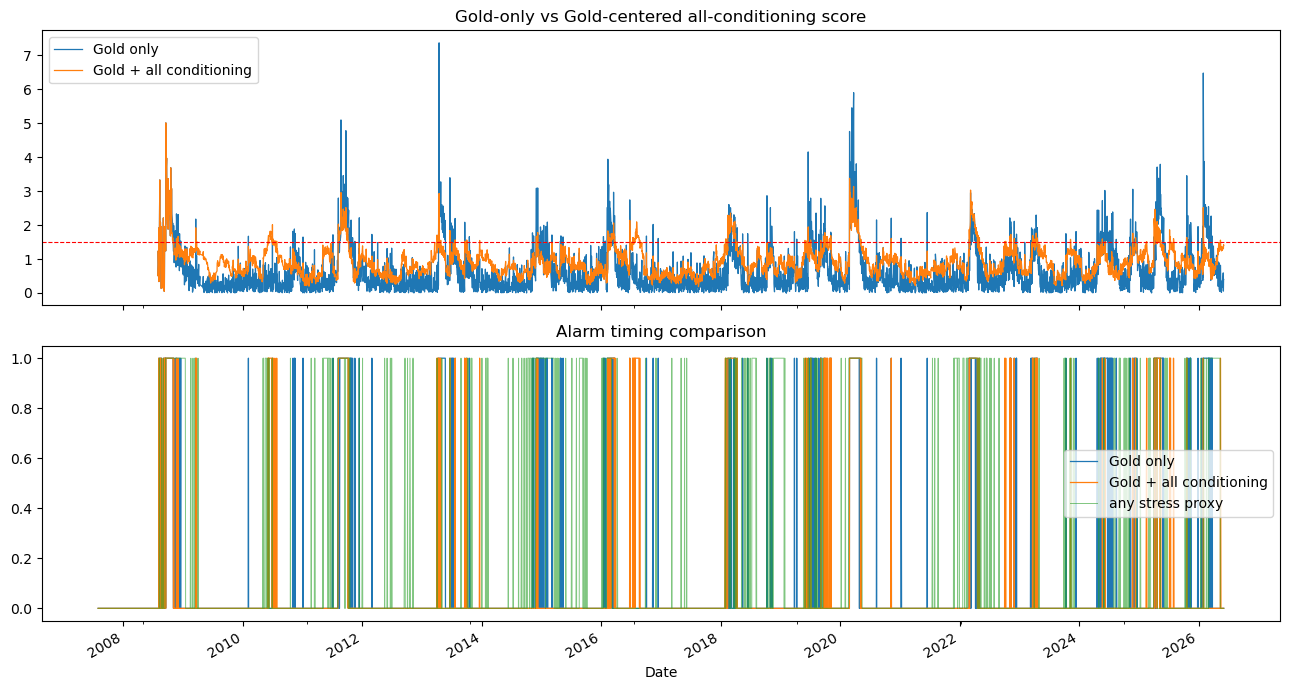

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

variant_scores[["Gold only", "Gold + all conditioning"]].plot(ax=axes[0], linewidth=0.9)
axes[0].axhline(THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axes[0].set_title("Gold-only vs Gold-centered all-conditioning score")

variant_alarms[["Gold only", "Gold + all conditioning"]].plot(ax=axes[1], linewidth=0.9)
stress["any_stress_proxy"].plot(ax=axes[1], linewidth=0.7, alpha=0.6, label="any stress proxy")
axes[1].legend()
axes[1].set_title("Alarm timing comparison")

plt.tight_layout()


## Step 05 Working Takeaways

This notebook makes the transition explicit:

- If Gold-only performs better than Gold + all conditioning, the final alarm should stay Gold-primary.
- If conditioning improves coverage or materially reduces review burden, the final alarm can become cross-market-conditioned.
- If a specific variable adds interpretation but weakens the signal, it should remain a diagnostic layer rather than a trigger input.

The next notebook should use this evidence to design the final alarm instead of assuming more variables are automatically better.


In [8]:
variant_scores.to_parquet(PROCESSED_DIR / "conditioning_variant_scores.parquet")
variant_alarms.to_parquet(PROCESSED_DIR / "conditioning_variant_alarms.parquet")
variant_comparison.to_csv(OUTPUT_DIR / "conditioning_variant_comparison.csv", index=False)
incremental_comparison.to_csv(OUTPUT_DIR / "conditioning_incremental_comparison.csv", index=False)

print("Saved Step 05 conditioning-variable selection outputs to:", OUTPUT_DIR)


Saved Step 05 conditioning-variable selection outputs to: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\outputs\step05_conditioning_selection
